# Phase 1: Prize Money Analysis

## Learning Objectives
1. Understand how PGA Tour prize money is distributed
2. Compare different tournament types (Majors vs Elevated vs Regular)
3. Build a model to predict prize money by finish position
4. Calculate expected value for fantasy golf decisions

## Why This Matters for Fantasy Golf
- Your scoring = total prize money earned by your 3 picks
- Understanding payout curves helps you evaluate risk/reward
- Top-heavy strategy = prioritize golfers with high win probability

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Step 1: Load and Clean Data

**Data Science Concept: Data Cleaning**
- Raw data often has formatting issues ($ signs, commas, inconsistent types)
- We need to convert text like "$1,260,000.00" into a number: 1260000.0
- This is called **data wrangling** or **data munging**

In [2]:
# Load the leaderboard data
leaderboard = pd.read_csv('tournament_leaderboards.csv')

print(f"Loaded {len(leaderboard):,} records")
print(f"\nColumns: {leaderboard.columns.tolist()}")
print(f"\nFirst few rows:")
leaderboard.tail()

FileNotFoundError: [Errno 2] No such file or directory: 'tournament_leaderboards.csv'

In [ ]:
# YOUR TASK: Clean the earnings column
# The earnings are stored as strings like "$1,260,000.00"
# We need to:
# 1. Remove the $ sign
# 2. Remove commas
# 3. Convert to float (decimal number)

# HINT: Use .str.replace() to remove characters
# HINT: Chain multiple .str.replace() calls together
# HINT: Use .astype(float) to convert to number

# YOUR CODE HERE:
leaderboard['earnings_clean'] = leaderboard['earnings'].astype(str).str.replace("$", "").str.replace(",", "") # Replace None with your code
leaderboard['earnings_clean'] = leaderboard['earnings_clean'].astype(float)
# Verify it worked
print("Original:", leaderboard['earnings'].iloc[0])
print("Cleaned:", leaderboard['earnings_clean'].iloc[0])

Original: $1,260,000.00
Cleaned: 1260000.0


## Step 2: Extract Finish Position Numbers

**Data Science Concept: Feature Engineering**
- The 'position' column has values like "1", "T5" (tied 5th), "T12"
- We need to extract just the NUMBER for analysis
- This is called **feature engineering** - creating useful features from raw data

In [ ]:
# YOUR TASK: Extract numeric position from strings like "T5" or "1"
# HINT: Use .str.replace('T', '') to remove the T
# HINT: Then convert to integer with .astype(int)

# YOUR CODE HERE:
leaderboard['position_num'] = leaderboard['position'].astype(str).str.replace("T", "")
leaderboard['position_num'] = pd.to_numeric(leaderboard['position_num'], errors='coerce')

leaderboard['made_cut'] = ~leaderboard['position'].isin(['CUT', 'W/D', 'DQ'])
leaderboard['missed_cut'] = leaderboard['position'] == 'CUT'
leaderboard['withdrawn'] = leaderboard['position'] == 'W/D'
leaderboard['disqualified'] = leaderboard['position'] == 'DQ'


print(f"\nPosition Extraction results:")
print(leaderboard[['position', 'position_num','made_cut']].head(15))


print(f"\nMade cut: {leaderboard['made_cut'].sum()} players")
print(f"Missed cut: {leaderboard['missed_cut'].sum()} players")
print(f"Withdrew: {leaderboard['withdrawn'].sum()} players")
print(f"DQ'd: {leaderboard['disqualified'].sum()} players")

    


Position Extraction results:
   position  position_num  made_cut
0         1           1.0      True
1         2           2.0      True
2         3           3.0      True
3        T4           4.0      True
4        T4           4.0      True
5        T4           4.0      True
6        T7           7.0      True
7        T7           7.0      True
8        T7           7.0      True
9        T7           7.0      True
10       T7           7.0      True
11       T7           7.0      True
12       T7           7.0      True
13       T7           7.0      True
14       T7           7.0      True

Made cut: 3023 players
Missed cut: 2308 players
Withdrew: 67 players
DQ'd: 2 players


## Step 3: Analyze the Payout Curve

**Key Question**: How does prize money decay as finish position gets worse?

Let's visualize this to understand the **risk/reward** profile.

In [ ]:
# Let's analyze one high-purse tournament in detail
# Filter for THE PLAYERS Championship 2025
players_champ = leaderboard[
    (leaderboard['tournament_name'] == 'THE PLAYERS Championship') & 
    (leaderboard['year'] == 2025)
].copy()

# Calculate percentage of total purse for each finish
total_purse = players_champ['earnings_clean'].sum()
players_champ['pct_of_purse'] = (players_champ['earnings_clean'] / total_purse * 100)

print(f"Total Purse: ${total_purse:,.2f}")
print(f"\nTop 20 finishers:")
players_champ.sort_values('position_num')[['position', 'player_name', 'earnings_clean', 'pct_of_purse']].head(20)

Total Purse: $25,362,250.00

Top 20 finishers:


,position,player_name,earnings_clean,pct_of_purse
3278,1,Rory McIlroy,4500000.0,17.742905
3279,2,J.J. Spaun,2725000.0,10.744315
3280,T3,Tom Hoge,1325000.0,5.224300
3281,T3,Akshay Bhatia,1325000.0,5.224300
3282,T3,Lucas Glover,1325000.0,5.224300
3283,T6,Danny Walker,843750.0,3.326795
3284,T6,Corey Conners,843750.0,3.326795
3285,T6,Bud Cauley,843750.0,3.326795
3286,9,Robert MacIntyre,731250.0,2.883222
3287,T10,Collin Morikawa,656250.0,2.587507


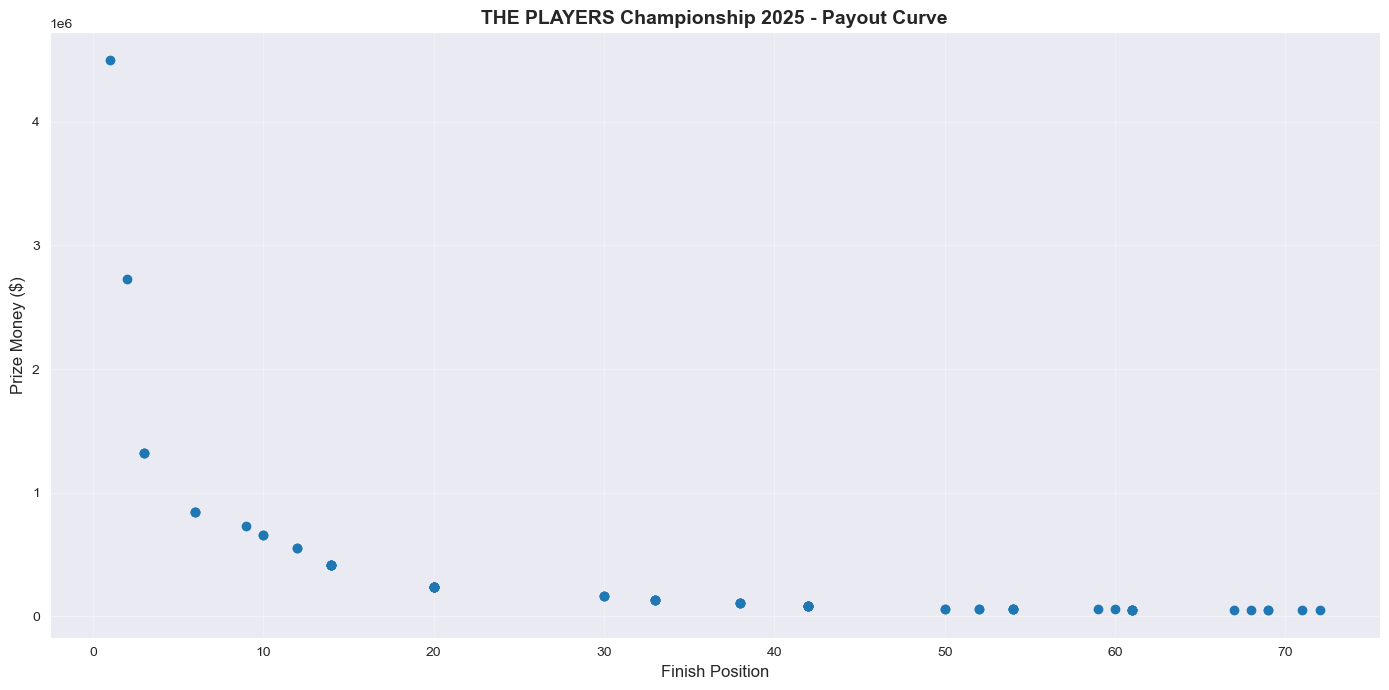


Your observation about the curve shape:
The Lower the finish position shows a higher payout and the higher finish position is a lower payout.


In [ ]:
# YOUR TASK: Create a visualization of the payout curve
# Plot position_num (x-axis) vs earnings_clean (y-axis)

# HINT: Use plt.plot() or plt.scatter()
# HINT: Sort by position_num first
# HINT: Add labels and title

# Sort the data
players_sorted = players_champ.sort_values('position_num')

# YOUR CODE HERE:
plt.figure(figsize=(14, 7))

# Create the plot (replace 'pass' with your code)
plt.scatter(players_champ['position_num'], players_champ['earnings_clean'])

plt.xlabel('Finish Position', fontsize=12)
plt.ylabel('Prize Money ($)', fontsize=12)
plt.title('THE PLAYERS Championship 2025 - Payout Curve', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# What pattern do you notice? Write your observation below:
print("\nYour observation about the curve shape:")
print("The Lower the finish position shows a higher payout and the higher finish position is a lower payout.")

## Step 4: Compare Tournament Types

**Strategic Question**: Are purses and payout structures different for:
- **Majors** (Masters, U.S. Open, PGA Championship, The Open)
- **Elevated Events** (THE PLAYERS, Genesis, Memorial, etc.)
- **Regular Events**

This matters because you want to allocate your limited golfer usages to the highest-value tournaments!

In [ ]:
# Calculate total purse for each tournament
tournament_purses = leaderboard.groupby(['tournament_name', 'year'])['earnings_clean'].agg([
    ('total_purse', 'sum'),
    ('winner_prize', 'max')
]).reset_index()

# Sort by purse size
tournament_purses = tournament_purses.sort_values('total_purse', ascending=False)

print("\nTop 15 Tournaments by Total Purse:")
print(tournament_purses.head(15).to_string(index=False))


Top 15 Tournaments by Total Purse:
                                   tournament_name  year  total_purse  winner_prize
                                 TOUR Championship  2025  40000000.02    10000000.0
                          THE PLAYERS Championship  2025  25362250.00     4500000.0
                                         U.S. Open  2025  20740000.00     4300000.0
                                Masters Tournament  2025  20648884.00     4200000.0
      the Memorial Tournament presented by Workday  2025  20335999.99     4000000.0
                          The Genesis Invitational  2025  20198000.02     4000000.0
                                      RBC Heritage  2025  20000000.04     3600000.0
                       FedEx St. Jude Championship  2025  20000000.03     3600000.0
Arnold Palmer Invitational presented by Mastercard  2025  19999999.99     4000000.0
                          AT&T Pebble Beach Pro-Am  2025  19935750.03     3600000.0
                               Truist Ch

In [ ]:
# YOUR TASK: Categorize tournaments as Major, Elevated, or Regular
# Create a new column 'tournament_type'

# Define the majors
majors = ['Masters Tournament', 'PGA Championship', 'U.S. Open', 'The Open Championship']

# Define elevated events (big purses, top fields)
elevated = [
    'THE PLAYERS Championship', 
    'The Genesis Invitational',
    'Arnold Palmer Invitational presented by Mastercard',
    'RBC Heritage',
    'the Memorial Tournament presented by Workday',
    'Travelers Championship',
    'AT&T Pebble Beach Pro-Am',
    'The Sentry'
]

playoff = [
    'FedEx St. Jude Championship', 'BMW Championship', 'TOUR Championship']
# YOUR CODE HERE:
# Create a function that categorizes each tournament

def categorize_tournament(name):
    if name in majors:
        return 'Major' 
    elif name in elevated:
        return 'Elevated' 
    elif name in playoff:
        return 'Playoff'
    else:
        return 'Regular'
tournament_purses['tournament_type'] = tournament_purses['tournament_name'].apply(categorize_tournament)

# Analyze purse differences by type
print("\nAverage Purse by Tournament Type:")
print(tournament_purses.groupby('tournament_type')['total_purse'].agg(['mean', 'min', 'max']))


Average Purse by Tournament Type:
                         mean          min          max
tournament_type                                        
Elevated         2.068775e+07  19812499.97  25362250.00
Major            1.898697e+07  15887002.00  20740000.00
Playoff          2.662200e+07  19866000.02  40000000.02
Regular          8.156521e+06   4016959.96  19889500.03


## Step 5: Build a Prize Money Prediction Model

**Machine Learning Concept**: We want to predict prize money for ANY finish position in ANY tournament.

We'll use a simple approach:
1. Calculate the **percentage of purse** for each finish position
2. Average across similar tournament types
3. Apply to future tournaments

This is called a **lookup table** or **reference model**.

In [ ]:
# Add tournament type to main leaderboard

# Check if we already added tournament_type
if 'tournament_type' not in leaderboard.columns:
    leaderboard = leaderboard.merge(
        tournament_purses[['tournament_name', 'year', 'tournament_type']], 
        on=['tournament_name', 'year'], 
        how='left'
    )
    print("✅ Tournament type added to leaderboard")
else:
    print("ℹ️ Tournament type already exists in leaderboard - skipping merge")
 
print(f"\nColumns in leaderboard: {leaderboard.columns.tolist()}")
print(f"\nSample data:")
print(leaderboard[['tournament_name', 'tournament_type', 'earnings_clean']].head())

# Calculate purse percentage for each record
leaderboard['pct_of_purse'] = leaderboard.groupby(['tournament_id'])['earnings_clean'].transform(
    lambda x: (x / x.sum() * 100)
)

# HINT: Use .groupby() with two columns: ['position_num', 'tournament_type']
# HINT: Calculate mean of 'pct_of_purse'

# YOUR CODE HERE:
payout_model = leaderboard.groupby(['tournament_type', 'position_num'], as_index=False)['pct_of_purse'].mean()  # Replace with your groupby code
print(payout_model)
print("\nPayout Model (first 30 positions for Majors):")
print(payout_model[payout_model['tournament_type'] == 'Major'].head(30))
                                

ℹ️ Tournament type already exists in leaderboard - skipping merge

Columns in leaderboard: ['tournament_id', 'tournament_name', 'year', 'player_id', 'player_name', 'position', 'total_score', 'to_par', 'fedex_points', 'earnings', 'rounds_played', 'earnings_clean', 'position_num', 'made_cut', 'missed_cut', 'withdrawn', 'disqualified', 'tournament_type', 'pct_of_purse']

Sample data:
   tournament_name tournament_type  earnings_clean
0  The RSM Classic         Regular      1260000.00
1  The RSM Classic         Regular       763000.00
2  The RSM Classic         Regular       483000.00
3  The RSM Classic         Regular       294583.33
4  The RSM Classic         Regular       294583.33
    tournament_type  position_num  pct_of_purse
0          Elevated           1.0     18.696741
1          Elevated           2.0     10.414845
2          Elevated           3.0      5.651842
3          Elevated           4.0      4.742130
4          Elevated           5.0      3.790028
..              ...   

## Step 6: Expected Value Calculation

**The Big Payoff**: Now we can calculate expected value!

**Expected Value (EV) Formula**:
```
EV = Σ (Probability of Finish Position × Prize Money for that Position)
```

For example, if a golfer has:
- 10% chance to win ($2M)
- 15% chance for 2nd ($1.2M)
- 20% chance for 3rd-5th (avg $700k)
- 30% chance for 6th-10th (avg $400k)
- 25% chance for 11th-20th (avg $200k)

EV = 0.10×2M + 0.15×1.2M + 0.20×700k + 0.30×400k + 0.25×200k = **$610k**

In [ ]:
# Let's create a simple EV calculator function
# We'll use this later with our prediction model

def calculate_expected_value(finish_probabilities, purse_size, tournament_type, payout_model):
    """
    Calculate expected prize money earnings.
    
    Parameters:
    -----------
    finish_probabilities : dict
        Dictionary mapping finish position to probability
        Example: {1: 0.10, 2: 0.15, 3: 0.20, ...}
    
    purse_size : float
        Total tournament purse (e.g., 20000000 for $20M)
    
    tournament_type : str
        'Major', 'Elevated', or 'Regular'
    
    payout_model : DataFrame
        The payout percentage lookup table
    
    Returns:
    --------
    float : Expected value in dollars
    """
    ev = 0
    
    for position, probability in finish_probabilities.items():
        # Get payout percentage for this position and tournament type
        payout_pct = payout_model[
            (payout_model['position_num'] == position) & 
            (payout_model['tournament_type'] == tournament_type)
        ]['pct_of_purse'].values
        
        if len(payout_pct) > 0:
            prize_money = (payout_pct[0] / 100) * purse_size
            ev += probability * prize_money
    
    return ev

# Test it with a hypothetical scenario
test_probabilities = {
    1: 0.10,   # 10% to win
    2: 0.10,   # 10% for 2nd
    3: 0.15,   # 15% for 3rd
    5: 0.20,   # 20% for T5
    10: 0.25,  # 25% for T10
    20: 0.20   # 20% for T20
}

# Calculate EV for THE PLAYERS Championship ($25M purse)
ev = calculate_expected_value(
    finish_probabilities=test_probabilities,
    purse_size=25000000,
    tournament_type='Elevated',
    payout_model=payout_model
)

print(f"\nExpected Value: ${ev:,.2f}")


Expected Value: $1,341,610.51


## 🎯 Summary & Next Steps

### What You've Learned:
1. **Data Cleaning**: Converting messy text data into usable numbers
2. **Feature Engineering**: Creating new useful features (position_num, tournament_type)
3. **Exploratory Data Analysis**: Understanding payout curves and distributions
4. **Modeling**: Building a reference model for prize predictions
5. **Expected Value**: The foundation of all good betting/fantasy decisions

### Key Insights:
- PGA Tour payouts are **highly top-heavy** (winner gets ~18-25% of purse)
- Majors and Elevated events have much larger purses
- For your **top-heavy strategy**, targeting wins in big purse events is optimal

### Next Phase:
Once you complete this notebook, we'll build:
- **Finish Position Prediction Model** (using your strokes gained data)
- Convert predictions into win/top-5/top-10 probabilities
- Combine with this payout model to get EV for each golfer

---

## 📝 Your Assignment:
1. Fill in all the "YOUR CODE HERE" sections
2. Run each cell and verify outputs
3. Answer the observation questions
4. Save the `payout_model` DataFrame - we'll use it in Phase 2!

**When you're done, let me know and we'll review your work together!**

In [ ]:
# Save the payout model for use in future notebooks
payout_model.to_csv('payout_model.csv', index=False)
print("Payout model saved successfully!")

Payout model saved successfully!
